In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

Reshaped x1 shape: (4, 1)
Reshaped y shape: (4,)
Linear SVM model trained successfully.
Classification Rule: 1.00*x + -1.50 = 0
Predicted class for x=3: 1


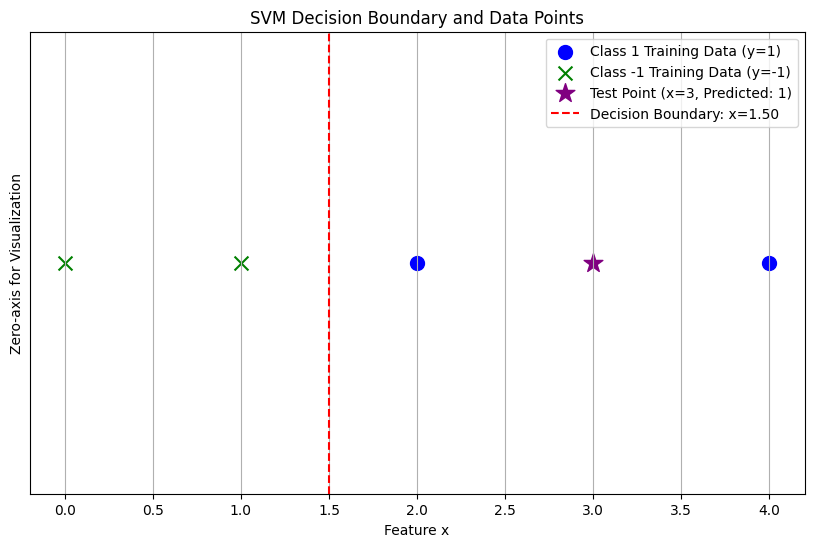

In [2]:
# Re-initialize x1 and y from their original definitions
x1 = np.array([[2,4,0,1]])
y = np.array([[1,1,-1,-1]])
# Reshape x1 to be a 2D array with one column
x1 = x1.reshape(-1, 1)
# Reshape y to be a 1D array
y = y.reshape(-1)
print(f"Reshaped x1 shape: {x1.shape}")
print(f"Reshaped y shape: {y.shape}")
# Instantiate a linear SVM classifier
svm_model = SVC(kernel='linear', random_state=42)
# Fit the model to the training data
svm_model.fit(x1, y)
print("Linear SVM model trained successfully.")
w = svm_model.coef_[0][0]
b = svm_model.intercept_[0]
print(f"Classification Rule: {w:.2f}*x + {b:.2f} = 0")
x_test = np.array([[3]])

# Predict the class label for the test input
y_pred_test = svm_model.predict(x_test)

print(f"Predicted class for x=3: {y_pred_test[0]}")



# Calculate the decision boundary
decision_boundary_x = -b / w

plt.figure(figsize=(10, 6))

# Plot training data points
# Separate points by class
plt.scatter(x1[y == 1].flatten(),
            np.zeros_like(x1[y == 1].flatten()),
            color='blue', marker='o', s=100,
            label='Class 1 Training Data (y=1)')

plt.scatter(x1[y == -1].flatten(),
            np.zeros_like(x1[y == -1].flatten()),
            color='green', marker='x', s=100,
            label='Class -1 Training Data (y=-1)')

# Plot the predicted test point
plt.scatter(x_test.flatten(),
            np.zeros_like(x_test.flatten()),
            color='purple', marker='*', s=200,
            label=f'Test Point (x=3, Predicted: {y_pred_test[0]})')

# Plot the decision boundary
plt.axvline(x=decision_boundary_x,
            color='red', linestyle='--',
            label=f'Decision Boundary: x={decision_boundary_x:.2f}')

# Labels and title
plt.xlabel('Feature x')
plt.ylabel('Zero-axis for Visualization')
plt.title('SVM Decision Boundary and Data Points')
plt.yticks([])

# Legend and grid
plt.legend()
plt.grid(True)
plt.show()


**2 input**

SVM Model: -0.00x1 + -1.00x2 + 2.00 = 0

Classification Rule:
If -0.00x1 + -1.00x2 + 2.00 > 0 → Class +1
If -0.00x1 + -1.00x2 + 2.00 < 0 → Class -1

Test Point (2,2) Predicted Class: 1
Margin: 2.0006


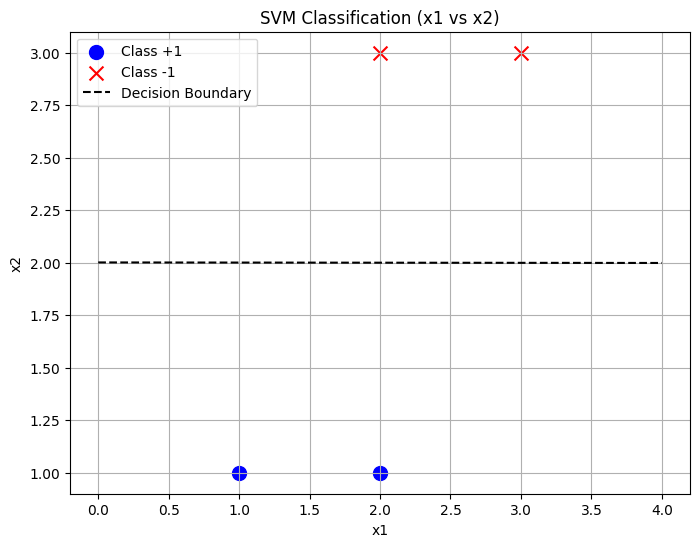

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Training dataset (two input features)
# Points: A, B, C, D
x1 = np.array([1, 2, 2, 3])
x2 = np.array([1, 1, 3, 3])
y  = np.array([1, 1, -1, -1])

# Combine features into (n_samples, n_features)
X = np.column_stack((x1, x2))

# Apply Linear SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X, y)

# Extract model parameters
w = svm_model.coef_[0]
b = svm_model.intercept_[0]

print(f"SVM Model: {w[0]:.2f}x1 + {w[1]:.2f}x2 + {b:.2f} = 0")

print("\nClassification Rule:")
print(f"If {w[0]:.2f}x1 + {w[1]:.2f}x2 + {b:.2f} > 0 → Class +1")
print(f"If {w[0]:.2f}x1 + {w[1]:.2f}x2 + {b:.2f} < 0 → Class -1")

# Test input (optional example)
x_test = np.array([[2, 2]])
y_pred = svm_model.predict(x_test)
print(f"\nTest Point (2,2) Predicted Class: {y_pred[0]}")

# ---- Margin Calculation ----
# Margin = 2 / ||w||
margin = 2 / np.linalg.norm(w)
print(f"Margin: {margin:.4f}")

# -------- Plotting --------
plt.figure(figsize=(8,6))

# Plot +1 class
plt.scatter(X[y==1][:,0], X[y==1][:,1],
            color='blue', marker='o', s=100, label='Class +1')

# Plot -1 class
plt.scatter(X[y==-1][:,0], X[y==-1][:,1],
            color='red', marker='x', s=100, label='Class -1')

# Plot decision boundary
x_vals = np.linspace(0, 4, 100)
# w0*x1 + w1*x2 + b = 0  →  x2 = -(w0*x1 + b)/w1
x2_vals = -(w[0]*x_vals + b) / w[1]
plt.plot(x_vals, x2_vals, 'k--', label='Decision Boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM Classification (x1 vs x2)')
plt.legend()
plt.grid(True)
plt.show()

**3 Input**

In [5]:
# Support vectors
X_sv = np.array([
    [0, -1, 1],
    [0, 2, -1],
    [-1, 0, 2]
])

# Corresponding labels
y_sv = np.array([1, -1, -1])

# Lagrange multipliers
alpha = np.array([1, 1, 1])

# Test input
x_test = np.array([0.2, 0.8, 0.4])

# Step 1: Compute weight vector w
w = np.sum(alpha[:, None] * y_sv[:, None] * X_sv, axis=0)
print(f"Weight vector w: {w}")

# Step 2: Compute bias b using the first support vector
b = y_sv[0] - np.dot(w, X_sv[0])
print(f"Bias b: {b}")

# Step 3: Compute decision function for test input
f_x = np.dot(w, x_test) + b
print(f"Decision function f(x_test): {f_x}")

# Step 4: Predicted class
y_pred = np.sign(f_x)
print(f"Predicted class label for x_test: {int(y_pred)}")

Weight vector w: [ 1 -3  0]
Bias b: -2
Decision function f(x_test): -4.2
Predicted class label for x_test: -1
